# Genetic Algorithm Hyperparameter Tuning
This notebook will show the outputs of the hyperparameter tuning. So this will be done in stages rather than a full grid search. In addition this will be done for only the moderate city, this is because if we used all three cities during tuning would conflate city structure with hyperparameter effects. You wouldn't know if a parameter setting is better because it's genuinely better or just better suited to that specific city.

Moderate city is the right choice for tuning because it's the middle ground — grid is too simple and bottleneck is too constrained. Once you've 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle

def extract_results(path):
    with open(path, "rb") as f:
        results = pickle.load(f)
    
    return results

In [3]:
import numpy as np
import pandas as pd


def summarise_experiment(results: dict, experiment_name: str) -> dict:
    evals = results["evals"]
    all_metrics = [e.metrics for e in evals]

    summary = {"experiment": experiment_name}
    for metric in all_metrics[0].keys():
        values = [m[metric] for m in all_metrics]
        summary[f"{metric} (mean)"] = round(float(np.mean(values)), 3)
        summary[f"{metric} (std)"] = round(float(np.std(values)), 3)

    return summary


def compare_experiments(filepaths: dict) -> pd.DataFrame:
    """
    filepaths: dict of {experiment_name: filepath}
    e.g. {
        "fitness_max": "results/fitness_max.pkl",
        "fitness_mean": "results/fitness_mean.pkl",
        "fitness_05max_05mean": "results/fitness_combo_05.pkl",
    }
    """
    rows = []
    for name, path in filepaths.items():
        results = extract_results(path)
        summary = summarise_experiment(results, name)
        rows.append(summary)

    df = pd.DataFrame(rows).set_index("experiment")
    return df


def print_comparison(df: pd.DataFrame, sort_by: str = "Total time (mean)") -> None:
    sorted_df = df.sort_values(sort_by)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)
    print(sorted_df.to_string())

### Fitness Function
The following parameters were tried first:
```
{"fitness": "max", "alpha": 1},
{"fitness": "mean", "alpha": 1},
{"fitness": "median", "alpha": 1},
{"fitness": "max-median", "alpha": 0.8},
{"fitness": "max-median", "alpha": 0.65},
{"fitness": "max-median", "alpha": 0.5}
```

Saved under the following name:
```
path = f"outputs/tuning/{city.city_name}_{n_experiments}_{params['fitness']}_{params['alpha']}_fitness.pkl"

>>outputs/tuning/moderate_city_3_{params['fitness']}_{params['alpha']}_fitness.pkl

```

In [4]:
filepaths = {
    "fitness_max":          "outputs/tuning/moderate_city_3_max_1_fitness.pkl",
    "fitness_mean":         "outputs/tuning/moderate_city_3_mean_1_fitness.pkl",
    "fitness_median":         "outputs/tuning/moderate_city_3_median_1_fitness.pkl",
    "fitness_08max_02median": "outputs/tuning/moderate_city_3_max-median_0.8_fitness.pkl",
    "fitness_065max_035median":       "outputs/tuning/moderate_city_3_max-median_0.65_fitness.pkl",
    "fitness_05max_05median": "outputs/tuning/moderate_city_3_max-median_0.5_fitness.pkl",
}


In [5]:
df = compare_experiments(filepaths)
print_comparison(df, sort_by="Total time (mean)")

                          Avg path length (mean)  Avg path length (std)  Total time (mean)  Total time (std)  Average time (mean)  Average time (std)  Congestion index (mean)  Congestion index (std)  Avg Congestion delay (mean)  Avg Congestion delay (std)  Exit utilisation (mean)  Exit utilisation (std)  Avg Path Efficiency (mean)  Avg Path Efficiency (std)
experiment                                                                                                                                                                                                                                                                                                                                                             
fitness_08max_02median                     8.980                  0.073             16.667             0.471               11.367               0.209                    0.857                   0.031                        2.387                       0.144                    0.092

In [6]:
df[['Avg path length (mean)', 'Total time (mean)', 'Average time (mean)', 'Congestion index (mean)', 
    'Avg Congestion delay (mean)', 'Exit utilisation (mean)', 'Avg Path Efficiency (mean)']].sort_values('Avg Congestion delay (mean)')


,Avg path length (mean),Total time (mean),Average time (mean),Congestion index (mean),Avg Congestion delay (mean),Exit utilisation (mean),Avg Path Efficiency (mean)
experiment,,,,,,,
fitness_mean,8.187,17.667,10.493,0.833,2.307,0.100,1.105
fitness_median,8.970,25.333,11.277,0.830,2.307,0.112,1.198
fitness_05max_05median,8.997,17.000,11.360,0.840,2.363,0.075,1.180
fitness_08max_02median,8.980,16.667,11.367,0.857,2.387,0.092,1.164
fitness_065max_035median,8.833,17.000,11.260,0.827,2.427,0.105,1.150
fitness_max,9.207,17.000,11.640,0.827,2.433,0.065,1.182


Clear winner is fitness_08max_02mean:
* Lowest total time (16.667) — the only config that gets below 17
* Lowest std on total time (0.471) — most consistent across seeds
* Lowest avg congestion delay (2.387)
* Best path efficiency (1.164) — agents taking reasonably direct routes

A few other observations:
* fitness_mean has the best average time (10.493) and shortest paths (8.187) but total time is worst (17.667) — it's optimising average at the expense of stragglers, which is wrong for evacuation
* fitness_median is clearly worst — total time 25.333 is terrible, drop it entirely
* fitness_065max has the best exit utilisation (0.105) but total time is inconsistent (std 0.816)
* fitness_max is completely flat (std 0.000) — confirms the earlier finding that pure max gives no gradient

### Epsilon
The following parameters were tried for the mutation greedy path and utilising the above parameters for fitness:
```
epsilon - [0, 0.2, 0.4, 0.6, 0.8, 1]
```

Saved under the following name:
```
path = f"outputs/tuning/{city.city_name}_{n_experiments}_{params['epsilon']}_epsilon.pkl"
>>outputs/tuning/moderate_city_3_{params['epsilon']}_epsilon.pkl
```

In [7]:
epsilon_filepaths = {
    "epsilon_0": "outputs/tuning/moderate_city_3_0_epsilon.pkl",
    "epsilon_02": "outputs/tuning/moderate_city_3_02_epsilon.pkl",
    "epsilon_04": "outputs/tuning/moderate_city_3_04_epsilon.pkl",
    "epsilon_06": "outputs/tuning/moderate_city_3_06_epsilon.pkl",
    "epsilon_08": "outputs/tuning/moderate_city_3_08_epsilon.pkl",
    "epsilon_1": "outputs/tuning/moderate_city_3_1_epsilon.pkl",
}

df_epsilon = compare_experiments(epsilon_filepaths)
df_epsilon[['Avg path length (mean)', 'Total time (mean)', 'Average time (mean)', 'Congestion index (mean)', 
    'Avg Congestion delay (mean)', 'Exit utilisation (mean)', 'Avg Path Efficiency (mean)']
           ].sort_values('Total time (mean)')

,Avg path length (mean),Total time (mean),Average time (mean),Congestion index (mean),Avg Congestion delay (mean),Exit utilisation (mean),Avg Path Efficiency (mean)
experiment,,,,,,,
epsilon_1,8.703,16.333,11.100,0.860,2.397,0.107,1.116
epsilon_08,8.790,17.000,11.137,0.823,2.347,0.118,1.151
epsilon_06,9.283,17.667,11.657,0.837,2.373,0.070,1.207
epsilon_04,9.047,17.667,11.427,0.840,2.380,0.102,1.201
epsilon_0,9.160,18.333,11.660,0.847,2.500,0.128,1.208
epsilon_02,9.347,18.667,11.767,0.843,2.420,0.083,1.214


In [9]:
folder_path = '../dissertation_images_and_stuff/hyperparameter_tuning_results/'

`epsilon = 1.0`

Greedy makes two decisions at every step:
1. Which exit to head to — always the nearest one
2. Which node to move to next — always the one closest to that exit

With epsilon=1.0 the GA mutation only affects decision 2 — path efficiency once an exit is chosen. Decision 1 — which exit — is entirely controlled by the GA's selection, crossover, and mutation exit assignment. The GA is still freely routing agents to exits that aren't the nearest one, which is the entire point.

### CrossOver 
The following parameters were tried for the mutation greedy path and utilising the above parameters for fitness:
```
crossover - [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
```

Saved under the following name:
```
path = f"outputs/tuning/{city.city_name}_{n_experiments}_{params['crossover']}_crossover.pkl"
>>outputs/tuning/moderate_city_3_{params['crossover']}_crossover.pkl
```

In [10]:
crossover_filepaths = {
    "crossover_04": "outputs/tuning/moderate_city_3_04_crossover.pkl",
    "crossover_05": "outputs/tuning/moderate_city_3_05_crossover.pkl",
    "crossover_06": "outputs/tuning/moderate_city_3_06_crossover.pkl",
    "crossover_07": "outputs/tuning/moderate_city_3_07_crossover.pkl",
    "crossover_08": "outputs/tuning/moderate_city_3_08_crossover.pkl",
    "crossover_09": "outputs/tuning/moderate_city_3_09_crossover.pkl",
}

df_crossover = compare_experiments(crossover_filepaths)
df_crossover[['Avg path length (mean)', 'Total time (mean)', 'Average time (mean)', 'Congestion index (mean)', 
    'Avg Congestion delay (mean)', 'Exit utilisation (mean)', 'Avg Path Efficiency (mean)']
           ].sort_values('Total time (mean)')


,Avg path length (mean),Total time (mean),Average time (mean),Congestion index (mean),Avg Congestion delay (mean),Exit utilisation (mean),Avg Path Efficiency (mean)
experiment,,,,,,,
crossover_08,8.713,15.667,11.207,0.877,2.493,0.145,1.135
crossover_09,8.653,16.000,11.040,0.840,2.387,0.097,1.114
crossover_04,8.950,16.333,11.457,0.860,2.507,0.058,1.167
crossover_05,8.680,16.333,11.103,0.843,2.423,0.100,1.127
crossover_07,8.523,16.333,10.920,0.843,2.397,0.088,1.128
crossover_06,8.813,16.333,11.167,0.827,2.353,0.097,1.148


In [11]:
folder_path = '../dissertation_images_and_stuff/hyperparameter_tuning_results/'
# df_crossover.to_csv(f'{folder_path}crossover.csv')

Crossover probability 0.8 shows the best results across the total time.

`Crossover 0.8`

### Mutation 
The following parameters were tried for the mutation greedy path and utilising the above parameters for fitness:
```
mutation - [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]
```

Saved under the following name:
```
path = f"outputs/tuning/{city.city_name}_{n_experiments}_{params['mutation']}_mutation.pkl"
>>outputs/tuning/moderate_city_3_{params['mutation']}_mutation.pkl
```

In [12]:
mutation_filepaths = {
    "mutation_001": "outputs/tuning/moderate_city_3_001_mutation.pkl",
    "mutation_005": "outputs/tuning/moderate_city_3_005_mutation.pkl",
    "mutation_01": "outputs/tuning/moderate_city_3_01_mutation.pkl",
    "mutation_02": "outputs/tuning/moderate_city_3_02_mutation.pkl",
    "mutation_03": "outputs/tuning/moderate_city_3_03_mutation.pkl",
    "mutation_04": "outputs/tuning/moderate_city_3_04_mutation.pkl",
}

df_mutation = compare_experiments(mutation_filepaths)
df_mutation[['Avg path length (mean)', 'Total time (mean)', 'Average time (mean)', 'Congestion index (mean)', 
    'Avg Congestion delay (mean)', 'Exit utilisation (mean)', 'Avg Path Efficiency (mean)']
           ].sort_values('Total time (mean)')


,Avg path length (mean),Total time (mean),Average time (mean),Congestion index (mean),Avg Congestion delay (mean),Exit utilisation (mean),Avg Path Efficiency (mean)
experiment,,,,,,,
mutation_001,8.357,15.000,10.830,0.877,2.473,0.088,1.116
mutation_005,8.570,16.000,10.880,0.833,2.310,0.093,1.133
mutation_01,8.623,16.000,11.100,0.837,2.477,0.147,1.148
mutation_02,8.867,16.333,11.317,0.853,2.450,0.087,1.129
mutation_03,8.863,16.667,11.350,0.850,2.487,0.098,1.133
mutation_04,8.790,17.000,11.210,0.870,2.420,0.073,1.147


In [13]:
folder_path = '../dissertation_images_and_stuff/hyperparameter_tuning_results/'
# df_mutation.to_csv(f'{folder_path}mutation.csv')

In [14]:
df_mutation

,Avg path length (mean),Avg path length (std),Total time (mean),Total time (std),Average time (mean),Average time (std),Congestion index (mean),Congestion index (std),Avg Congestion delay (mean),Avg Congestion delay (std),Exit utilisation (mean),Exit utilisation (std),Avg Path Efficiency (mean),Avg Path Efficiency (std)
experiment,,,,,,,,,,,,,,
mutation_001,8.357,0.237,15.000,0.000,10.830,0.255,0.877,0.005,2.473,0.076,0.088,0.052,1.116,0.014
mutation_005,8.570,0.107,16.000,0.000,10.880,0.233,0.833,0.005,2.310,0.128,0.093,0.047,1.133,0.029
mutation_01,8.623,0.261,16.000,0.816,11.100,0.427,0.837,0.017,2.477,0.192,0.147,0.031,1.148,0.042
mutation_02,8.867,0.109,16.333,0.471,11.317,0.111,0.853,0.031,2.450,0.054,0.087,0.006,1.129,0.022
mutation_03,8.863,0.038,16.667,0.471,11.350,0.116,0.850,0.000,2.487,0.110,0.098,0.015,1.133,0.025
mutation_04,8.790,0.198,17.000,0.000,11.210,0.171,0.870,0.022,2.420,0.037,0.073,0.008,1.147,0.016


Need to double check these have converged so running the same again with `_100` on the end to represent the increase in max evolutions.

In [15]:
mutation_filepaths_100 = {
    "mutation_001": "outputs/tuning/moderate_city_3_001_mutation_100.pkl",
    "mutation_005": "outputs/tuning/moderate_city_3_005_mutation_100.pkl",
    "mutation_01": "outputs/tuning/moderate_city_3_01_mutation_100.pkl",
    "mutation_02": "outputs/tuning/moderate_city_3_02_mutation_100.pkl",
    "mutation_03": "outputs/tuning/moderate_city_3_03_mutation_100.pkl",
    # "mutation_04": "outputs/tuning/moderate_city_3_04_mutation_100.pkl",
}

df_mutation_100 = compare_experiments(mutation_filepaths_100)
df_mutation_100[['Avg path length (mean)', 'Total time (mean)', 'Average time (mean)', 'Congestion index (mean)', 
    'Avg Congestion delay (mean)', 'Exit utilisation (mean)', 'Avg Path Efficiency (mean)']
           ].sort_values('Total time (mean)')


,Avg path length (mean),Total time (mean),Average time (mean),Congestion index (mean),Avg Congestion delay (mean),Exit utilisation (mean),Avg Path Efficiency (mean)
experiment,,,,,,,
mutation_001,8.537,15.000,10.937,0.840,2.400,0.125,1.126
mutation_005,8.540,15.667,10.927,0.840,2.387,0.110,1.116
mutation_01,8.820,16.333,11.213,0.837,2.393,0.082,1.156
mutation_02,8.747,16.333,11.180,0.853,2.433,0.088,1.129
mutation_03,8.780,16.333,11.217,0.850,2.437,0.070,1.145


In [16]:
folder_path = '../dissertation_images_and_stuff/hyperparameter_tuning_results/'
# df_mutation_100.to_csv(f'{folder_path}mutation_100.csv')

**Evolutions**

Tuning runs: 50 evolutions — sufficient to differentiate configs, validated by comparing 50 vs 100 evolution results which showed consistent rankings
Final experiments: 100 evolutions — gives best solutions time to converge

**Mutation rate**

Selected: `mutation=0.05`
Rejected mutation=0.01 despite better total time (15.000 vs 15.667) because with 100 agents only 63% of chromosomes mutate per generation, limiting exploration. mutation=0.05 ensures 99.4% of chromosomes mutate each generation which is more theoretically sound and consistent with standard GA literature
Rejected mutation=0.1 and above as performance degrades monotonically beyond 0.05

### Population Size 
The following parameters were tried for the population size:
```
pop_size - [5, 10, 20, 50, 100, 200]
```

Saved under the following name:
```
path = f"outputs/tuning/{city.city_name}_{n_experiments}_{pop_size}_pop_size.pkl"
```

In [17]:
pop_size_filepaths = {
    "pop_size_5": "outputs/tuning/moderate_city_3_5_pop_size.pkl",
    "pop_size_10": "outputs/tuning/moderate_city_3_10_pop_size.pkl",
    "pop_size_20": "outputs/tuning/moderate_city_3_20_pop_size.pkl",
    "pop_size_50": "outputs/tuning/moderate_city_3_50_pop_size.pkl",
    "pop_size_100": "outputs/tuning/moderate_city_3_100_pop_size.pkl",
    "pop_size_200": "outputs/tuning/moderate_city_3_200_pop_size.pkl",
}

df_pop_size = compare_experiments(pop_size_filepaths)
# df_pop_size[['Avg path length (mean)', 'Total time (mean)', 'Average time (mean)', 'Congestion index (mean)', 
#     'Avg Congestion delay (mean)', 'Exit utilisation (mean)', 'Avg Path Efficiency (mean)']
#            ].sort_values('Total time (mean)')
df_pop_size

,Avg path length (mean),Avg path length (std),Total time (mean),Total time (std),Average time (mean),Average time (std),Congestion index (mean),Congestion index (std),Avg Congestion delay (mean),Avg Congestion delay (std),Exit utilisation (mean),Exit utilisation (std),Avg Path Efficiency (mean),Avg Path Efficiency (std)
experiment,,,,,,,,,,,,,,
pop_size_5,9.297,0.246,20.667,0.471,11.803,0.313,0.853,0.009,2.507,0.132,0.100,0.036,1.233,0.031
pop_size_10,8.973,0.137,17.000,0.000,11.433,0.159,0.847,0.009,2.460,0.171,0.092,0.012,1.172,0.005
pop_size_20,8.553,0.209,16.000,0.000,10.973,0.162,0.843,0.017,2.420,0.107,0.148,0.013,1.131,0.016
pop_size_50,8.667,0.239,15.667,0.471,10.993,0.351,0.843,0.017,2.327,0.158,0.080,0.019,1.132,0.020
pop_size_100,8.407,0.161,15.333,0.471,10.717,0.254,0.840,0.008,2.310,0.098,0.057,0.002,1.100,0.022
pop_size_200,8.183,0.066,15.000,0.000,10.513,0.017,0.850,0.008,2.330,0.050,0.093,0.027,1.082,0.011


In [18]:
folder_path = '../dissertation_images_and_stuff/hyperparameter_tuning_results/'
# df_pop_size.to_csv(f'{folder_path}pop_size.csv')

`Population size of 50` was selected as it achieves competitive total evacuation time (15.667) with manageable computational cost, with larger populations showing diminishing returns — `pop_200` improves total time by only 0.667 timesteps at four times the computational expense.

## Phase 2 — Structural parameters
This phase will test the following:
* `Survivor selection: [elite, elite_percentage, children]`
* `Parent selection: [roulette, tournament_3, tournament_5]`

In [19]:
phase2_filepaths = {
    "Children Roulette": "outputs/tuning/moderate_city_20_survivor_children_parent_rouletteNone.pkl",
    "Children Tournament 3": "outputs/tuning/moderate_city_20_survivor_children_parent_tournament3.pkl",
    "Children Tournament 5": "outputs/tuning/moderate_city_20_survivor_children_parent_tournament5.pkl",
    "Elite Roulette": "outputs/tuning/moderate_city_20_survivor_elite_parent_rouletteNone.pkl",
    "Elite Tournament 3": "outputs/tuning/moderate_city_20_survivor_elite_parent_tournament3.pkl",
    "Elite Tournament 5": "outputs/tuning/moderate_city_20_survivor_elite_parent_tournament5.pkl",
    "Elite % Roulette": "outputs/tuning/moderate_city_20_survivor_elite_percentage_parent_rouletteNone.pkl",
    "Elite % Tournament 3": "outputs/tuning/moderate_city_20_survivor_elite_percentage_parent_tournament3.pkl",
    "Elite % Tournament 5": "outputs/tuning/moderate_city_20_survivor_elite_percentage_parent_tournament5.pkl",
}

df_phase2 = compare_experiments(phase2_filepaths)
df_phase2[[
    'Avg path length (mean)', 'Total time (mean)', 
    'Average time (mean)', 'Congestion index (mean)', 
    'Avg Congestion delay (mean)', 'Exit utilisation (mean)', 
    'Avg Path Efficiency (mean)']
].sort_values('Avg Congestion delay (mean)')

,Avg path length (mean),Total time (mean),Average time (mean),Congestion index (mean),Avg Congestion delay (mean),Exit utilisation (mean),Avg Path Efficiency (mean)
experiment,,,,,,,
Elite Tournament 3,8.412,15.15,10.737,0.839,2.325,0.100,1.115
Elite % Tournament 5,8.492,15.20,10.843,0.846,2.351,0.098,1.119
Elite Roulette,8.399,15.20,10.755,0.844,2.356,0.084,1.109
Elite % Roulette,8.555,15.80,10.913,0.846,2.358,0.096,1.122
Elite Tournament 5,8.426,15.25,10.787,0.844,2.361,0.090,1.118
Children Tournament 3,8.503,15.85,10.865,0.845,2.362,0.081,1.093
Elite % Tournament 3,8.434,15.25,10.802,0.843,2.367,0.099,1.123
Children Tournament 5,8.412,15.55,10.797,0.854,2.385,0.092,1.102
Children Roulette,9.068,17.95,11.588,0.864,2.519,0.100,1.142


In [20]:
folder_path = '../dissertation_images_and_stuff/hyperparameter_tuning_results/'
# df_phase2.to_csv(f'{folder_path}selection.csv')

Children configs are clearly worst — Children Roulette (18.1) and even Children Tournament 3/5 (15.7-15.9) underperform across the board. Without elitism the population degrades too easily, which confirms keeping elitism.

Elite vs Elite % — very similar performance, Elite Roulette (15.2) is close but Elite % Tournament 3 edges it on total time and average time.

Tournament vs Roulette — tournament consistently outperforms roulette within each survivor method, which makes sense — tournament selection applies more selection pressure by actively comparing candidates.

Tournament size 3 vs 5 — size 3 wins over size 5 in both Elite and Elite % configs. Size 5 introduces too much selection pressure, reducing diversity.

In [21]:
from utils.plots import (
    plot_parent_selection_stats,
    plot_survivor_selection,
    plot_covergence,
    plot_fitness_vs_time
)

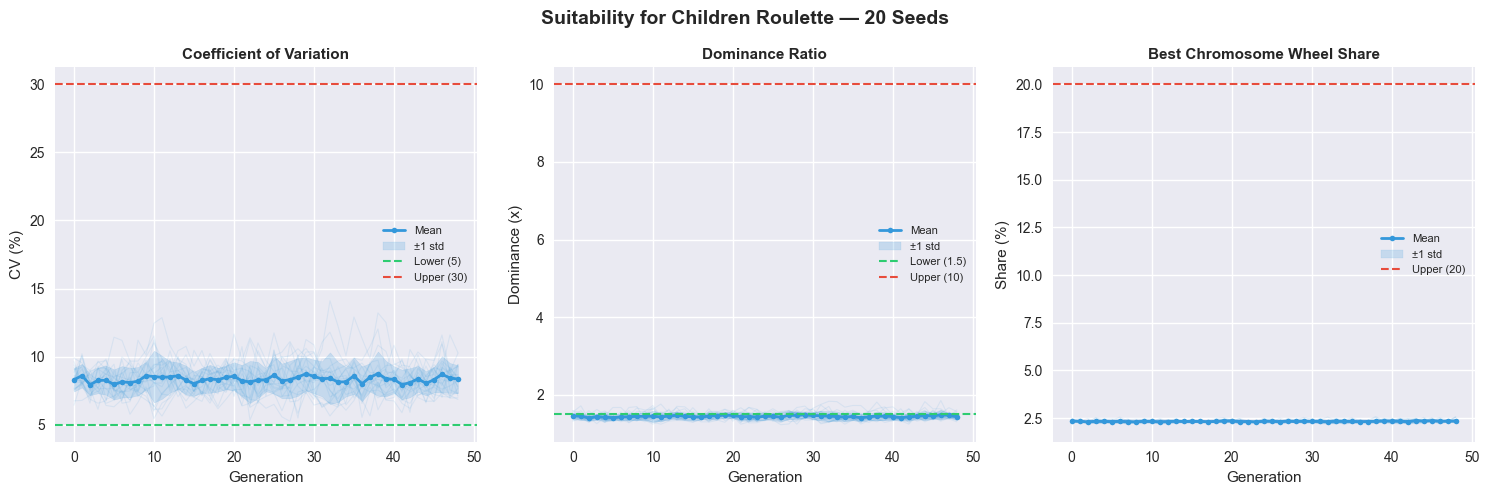

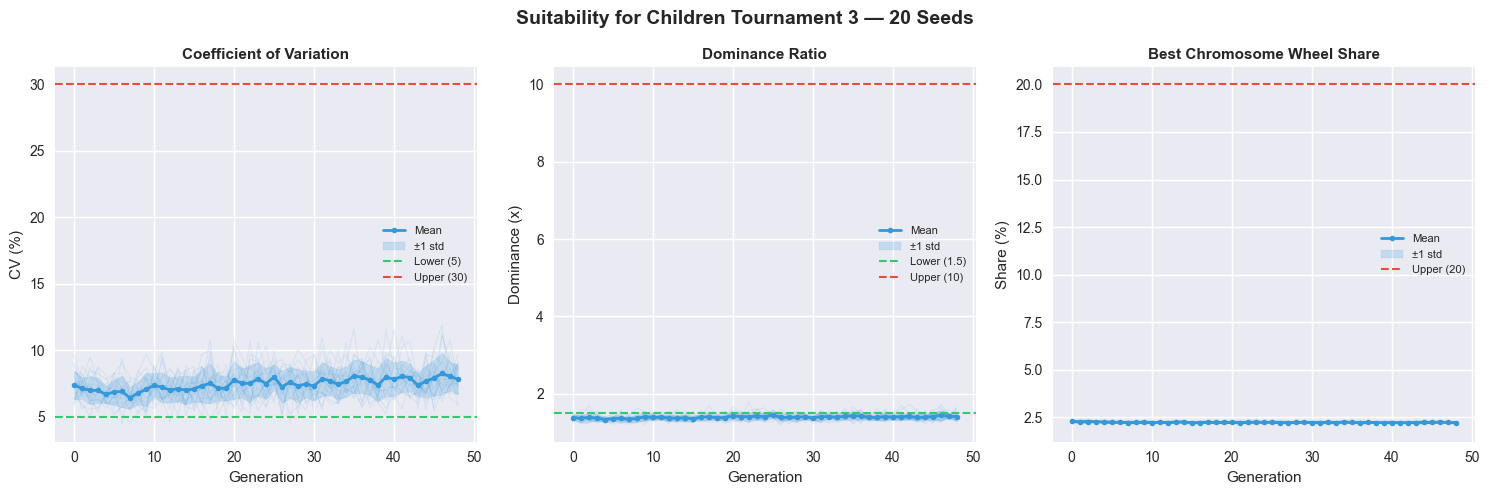

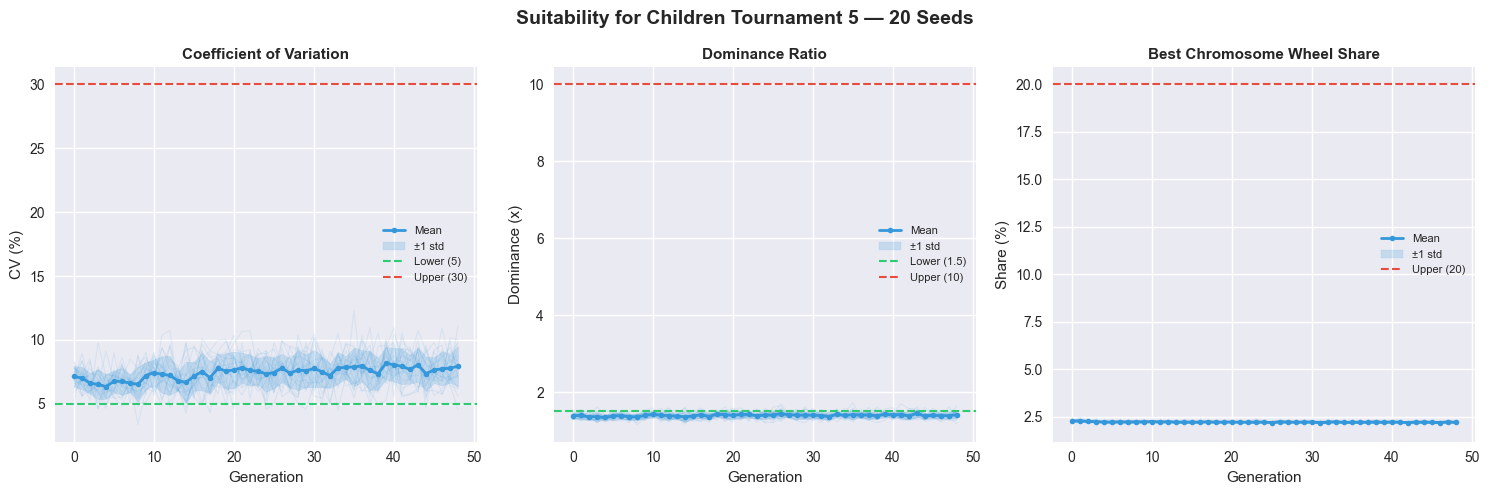

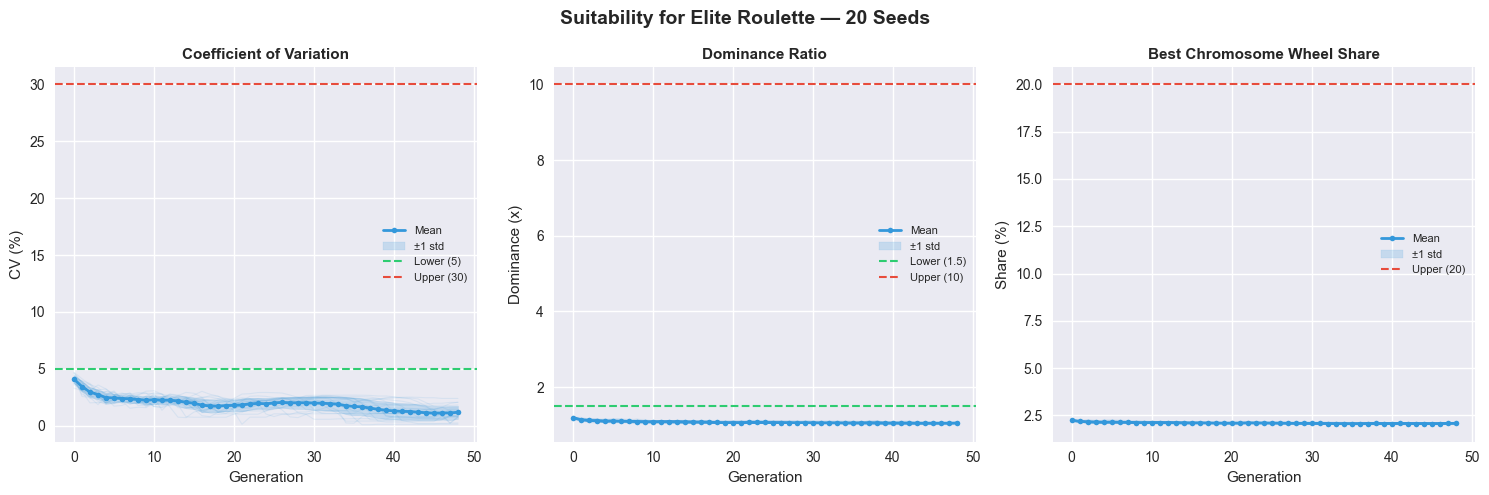

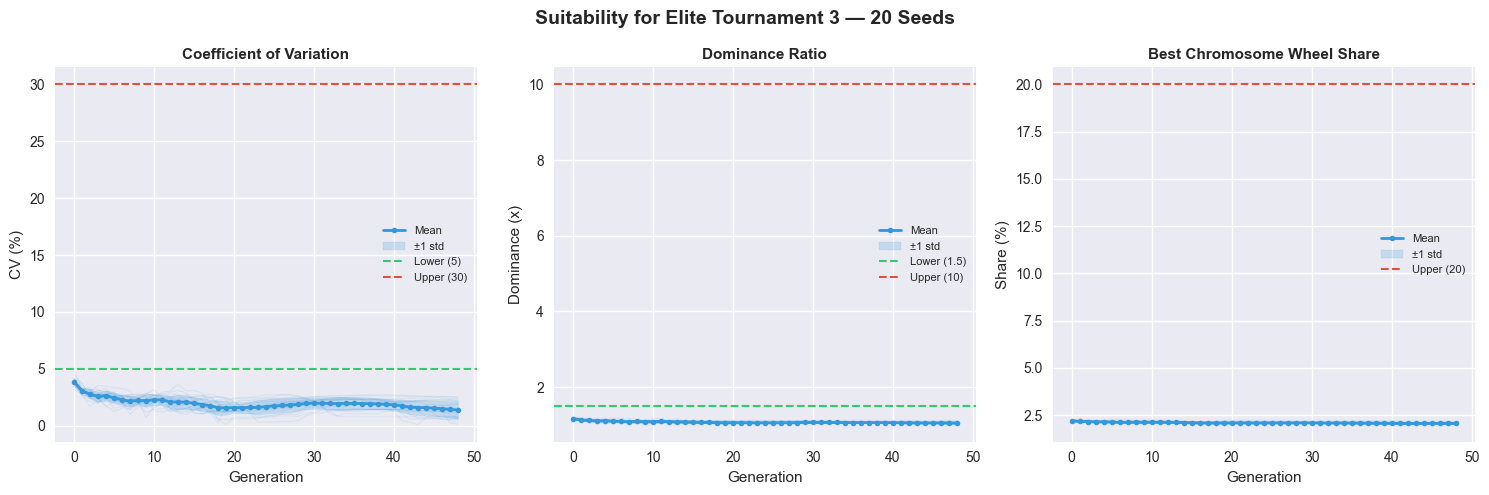

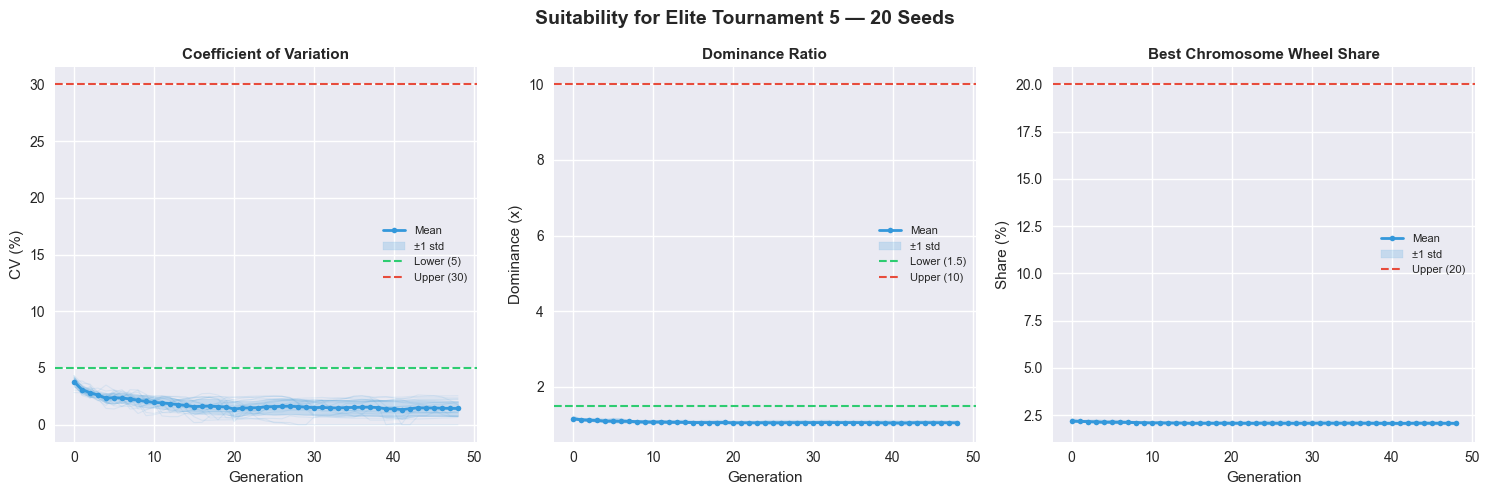

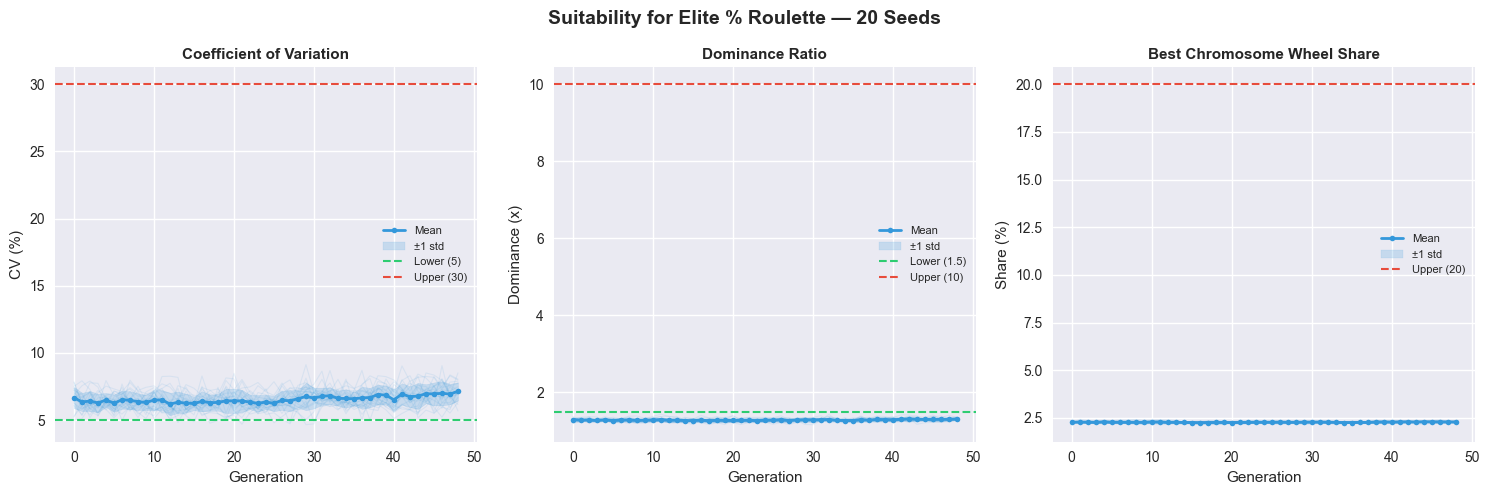

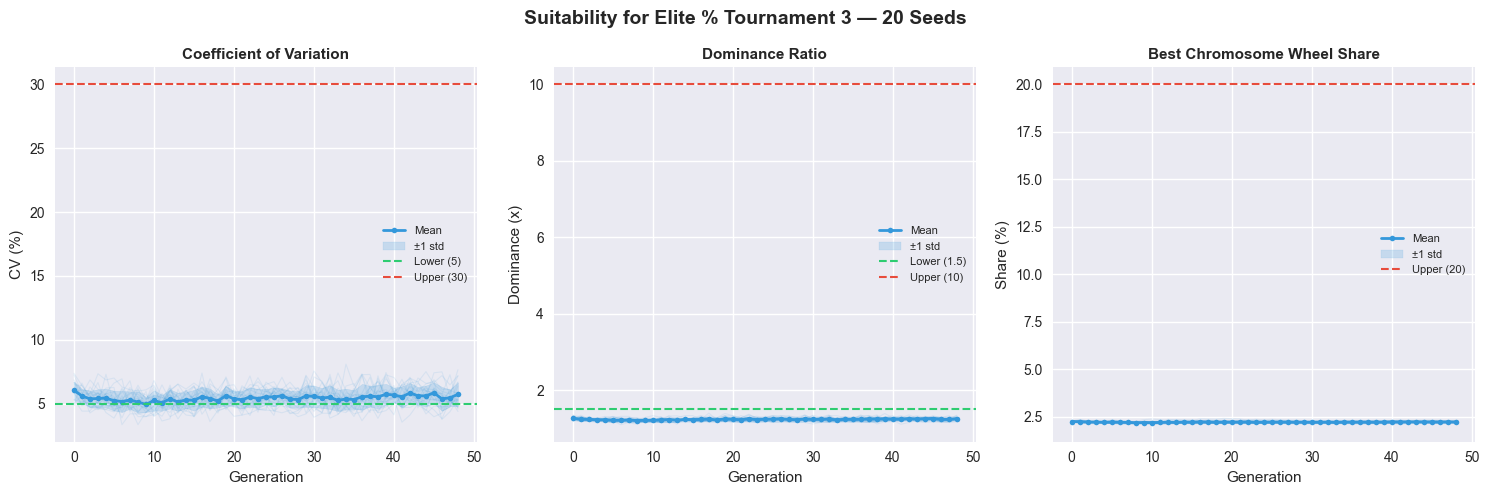

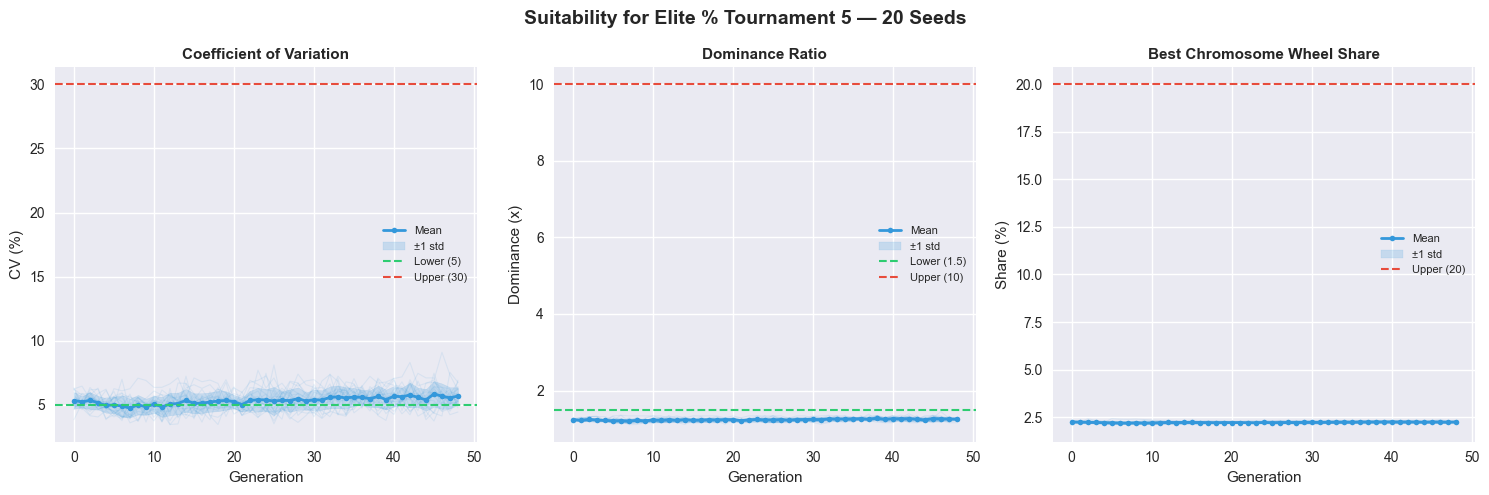

In [45]:
phase2_results = {}
for name, path in phase2_filepaths.items():
    results = extract_results(path)
    phase2_results[name] = results
    
    plot_parent_selection_stats(
        evolution_stats=results['evals'],
        city_name=name,
    )


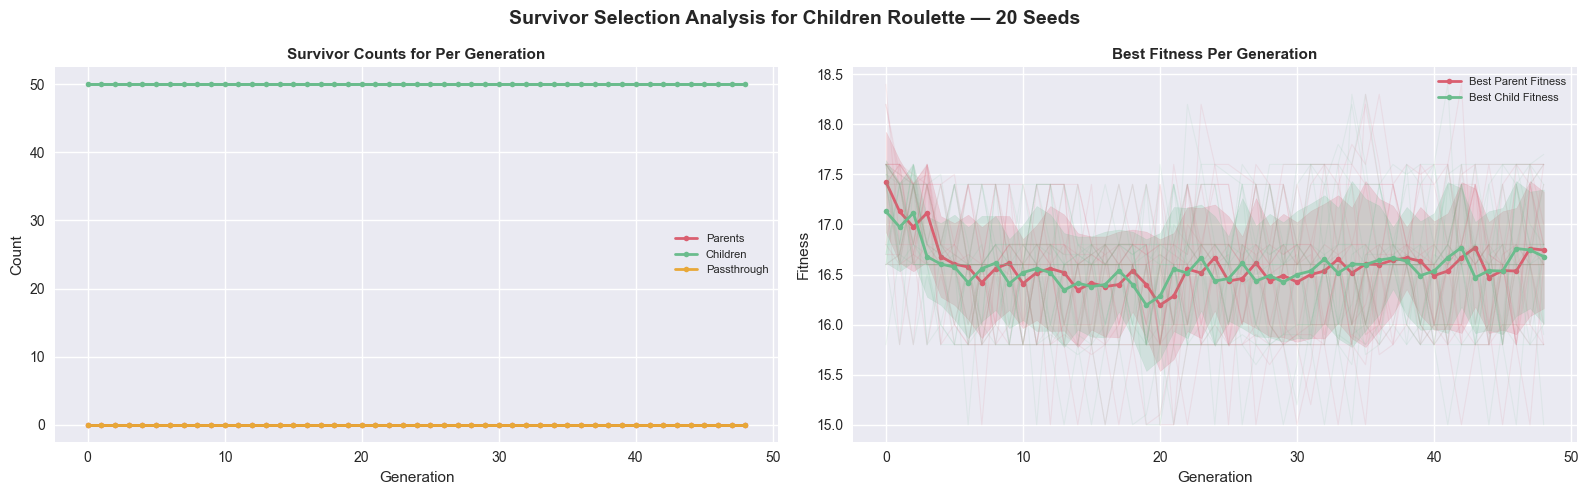

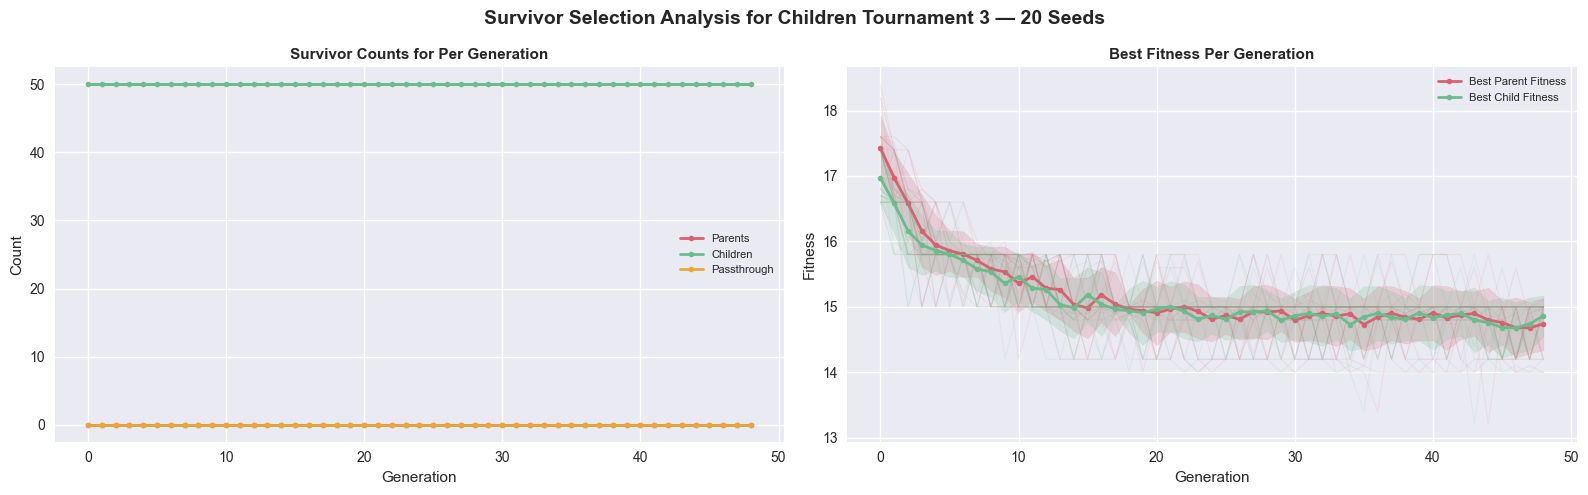

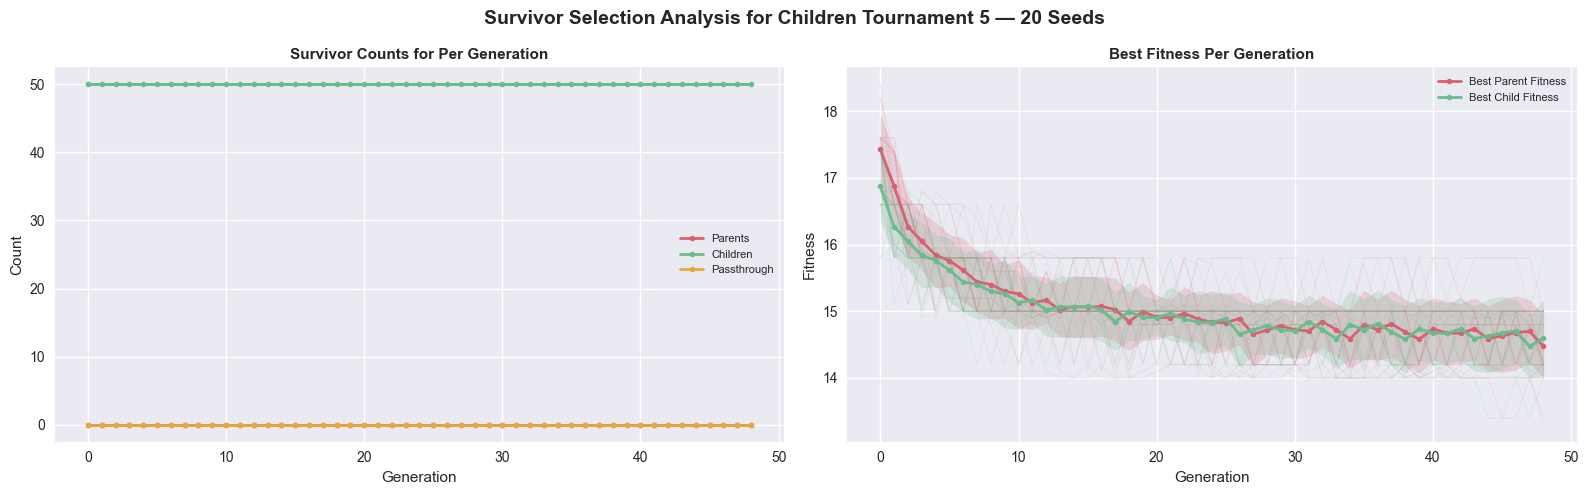

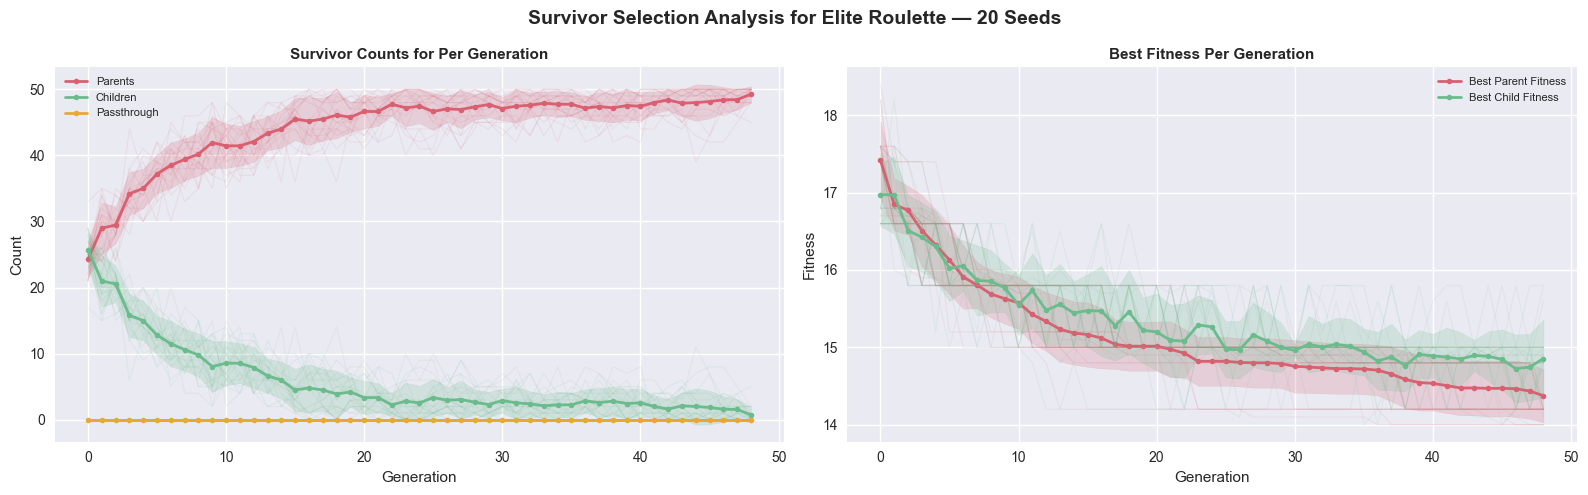

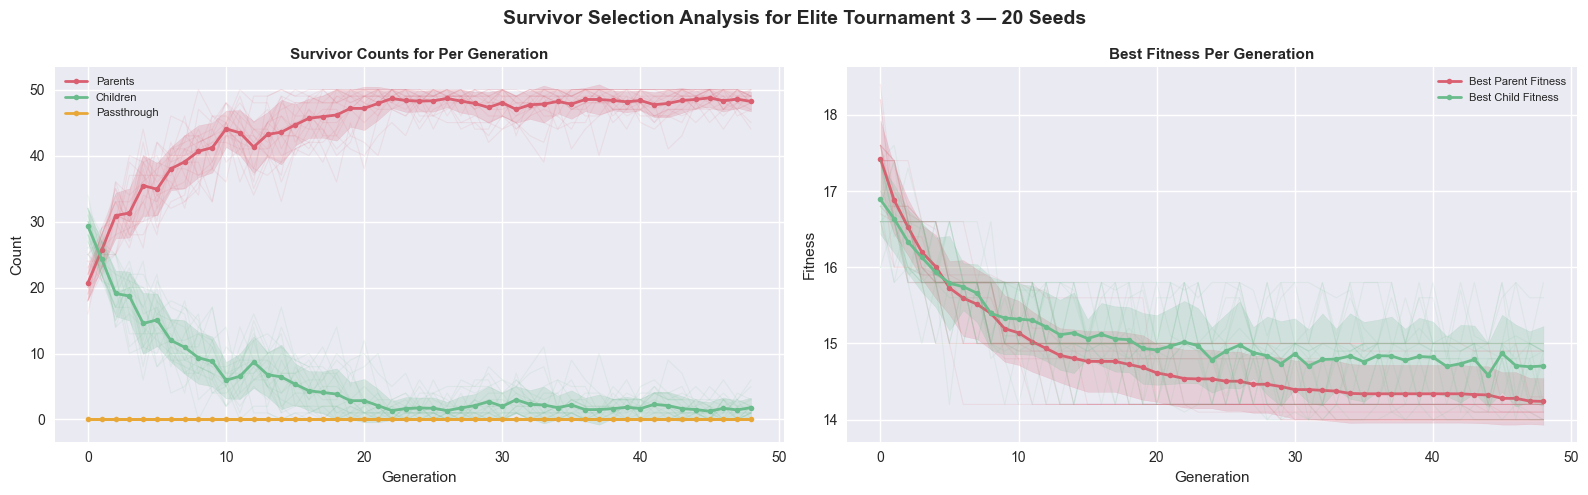

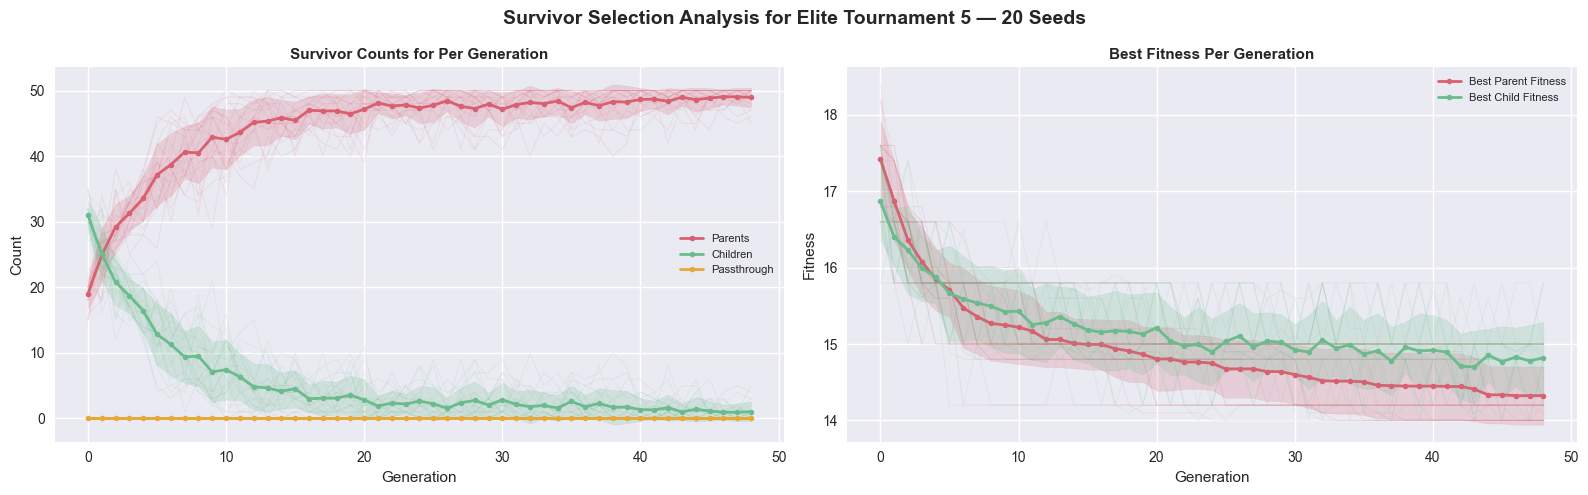

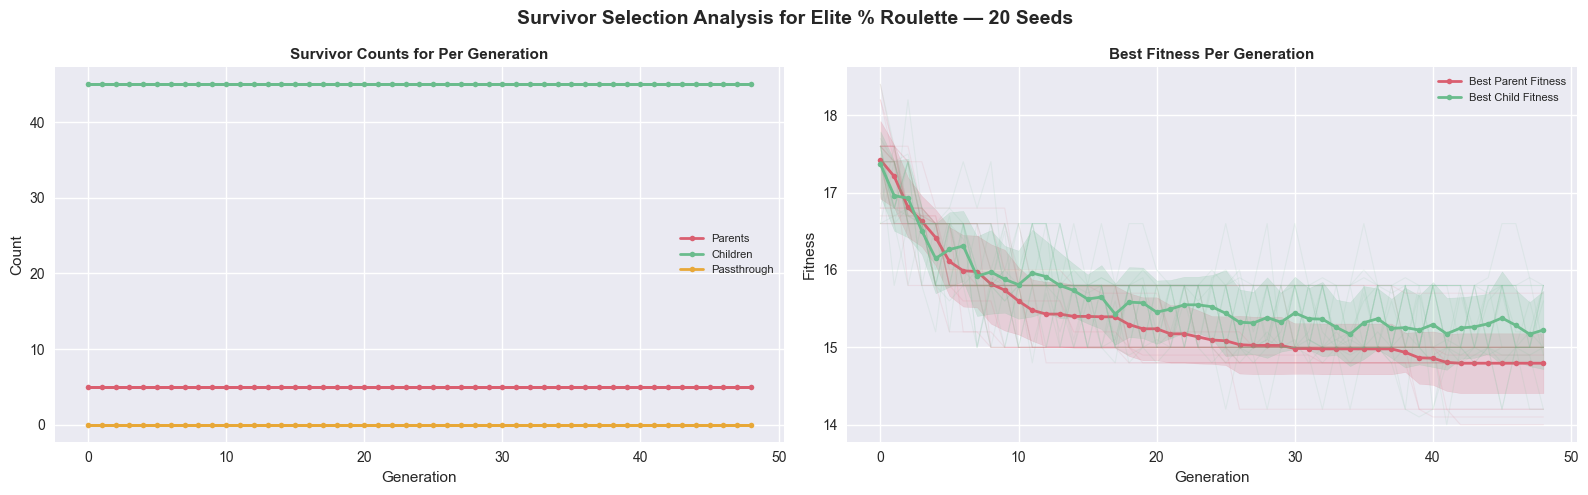

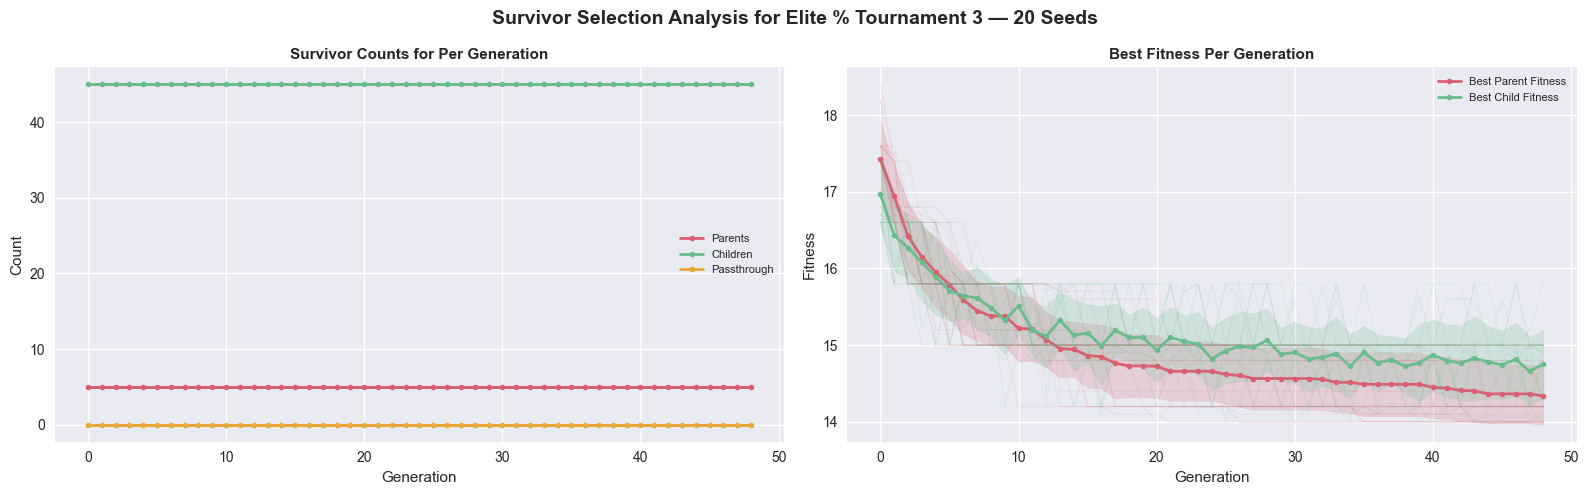

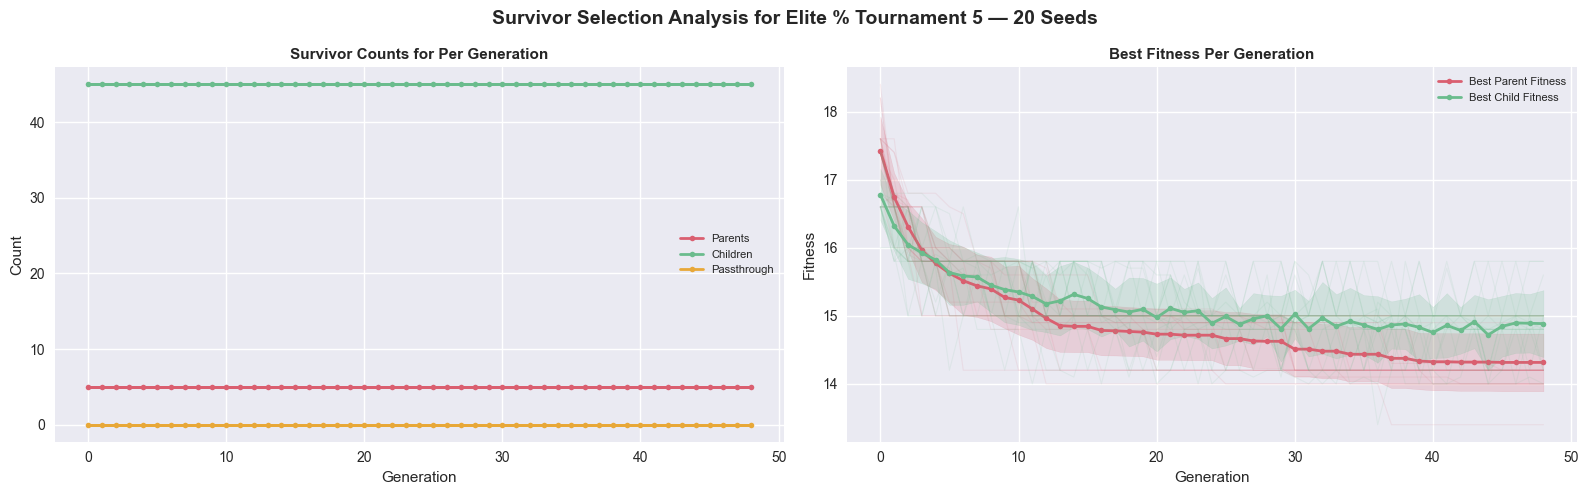

In [55]:
for name, results in phase2_results.items():
    plot_survivor_selection(
        evolution_stats=results['evals'],
        city_name=name
    )

Children configs (images 1-3): CV stays flat at ~8% throughout all 50 generations — the population never converges, it's just randomly searching. No learning happening.

Elite configs (images 4-6): CV drops steeply from ~4% to ~1% by generation 20 then flatlines — converges too aggressively, loses diversity early

Elite % configs (images 7-9): CV starts at ~6% and stays stable around 5% throughout — healthy balance of exploration and exploitation

`Elite % Tournament 3 maintains healthier diversity throughout and still potentially improving after 50 evolutions.`

CV plot (this image) — sitting right at the lower boundary of 5% throughout. This means the population has just enough diversity to keep exploring but is right on the edge of being too homogeneous. Not alarming but worth noting.

Dominance ratio — hugging the lower bound of 1.5, meaning the best chromosome is only marginally better than average. This is actually healthy — it means selection pressure isn't too aggressive and the whole population is competitive.

Best chromosome wheel share — flat at 2.5%, well below the upper bound of 20%. The best solution isn't dominating selection, which is good for diversity.

The concern is the CV being right at the lower boundary. It means the population is on the edge of premature convergence but hasn't tipped over. At 100 evolutions this could go either way — it might maintain diversity or slowly collapse below 5%.

Will increase the mutation rate up to 0.1 to inject more diversity and push the CV up above the lower boundary.

#### Rerunning for 1 seed to see if plots are better than might need to rerun the rest.
* Mutation = 0.1
* Rerunning survivor selection analysis so that actually do a propoer overlap calculation.


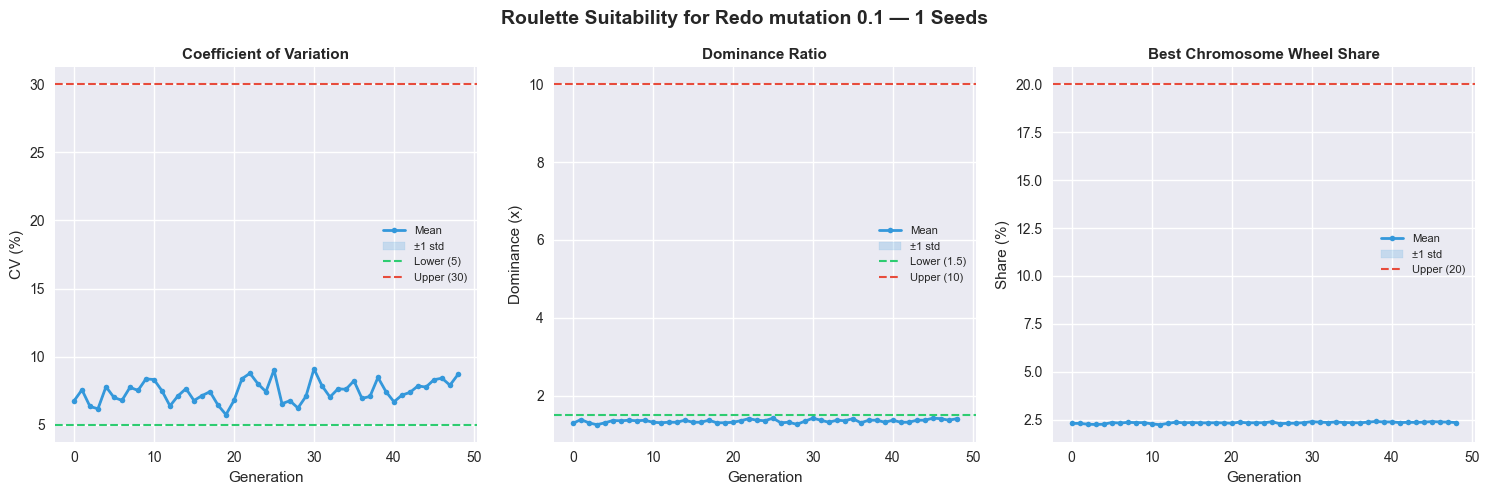

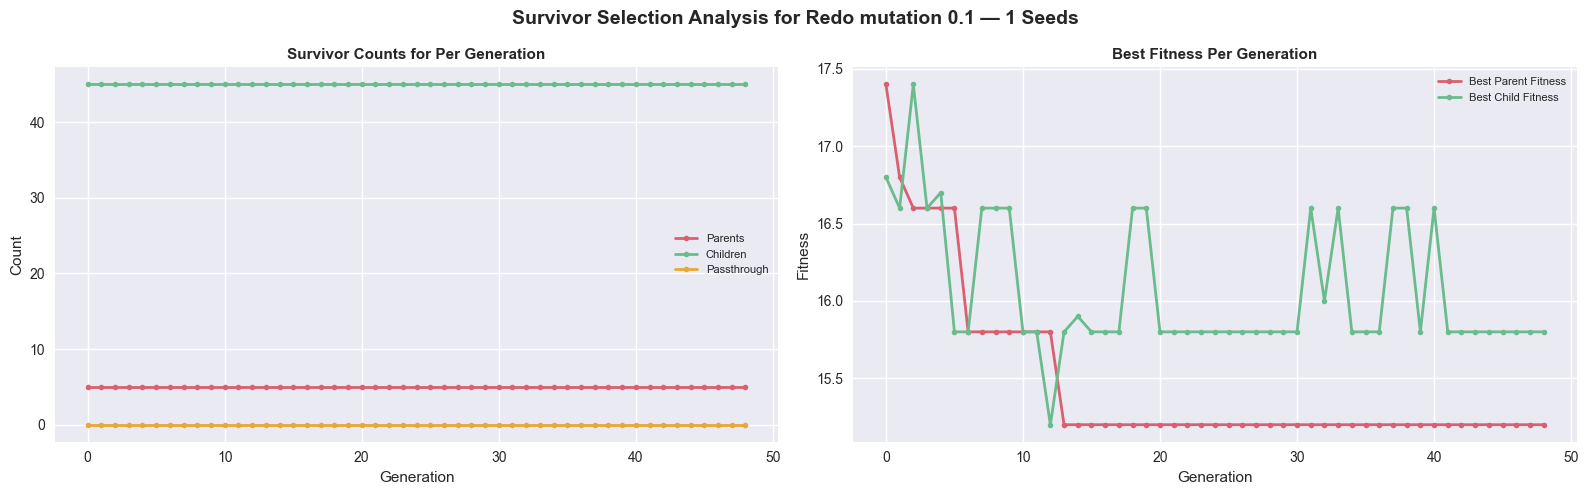

In [25]:
redo_results = extract_results('outputs/tuning/moderate_city_1_test1.pkl')

plot_parent_selection_stats(evolution_stats=redo_results['evals'],city_name="Redo Mutation 0.1")
plot_survivor_selection(evolution_stats=redo_results['evals'],city_name="Redo Mutation 0.1")


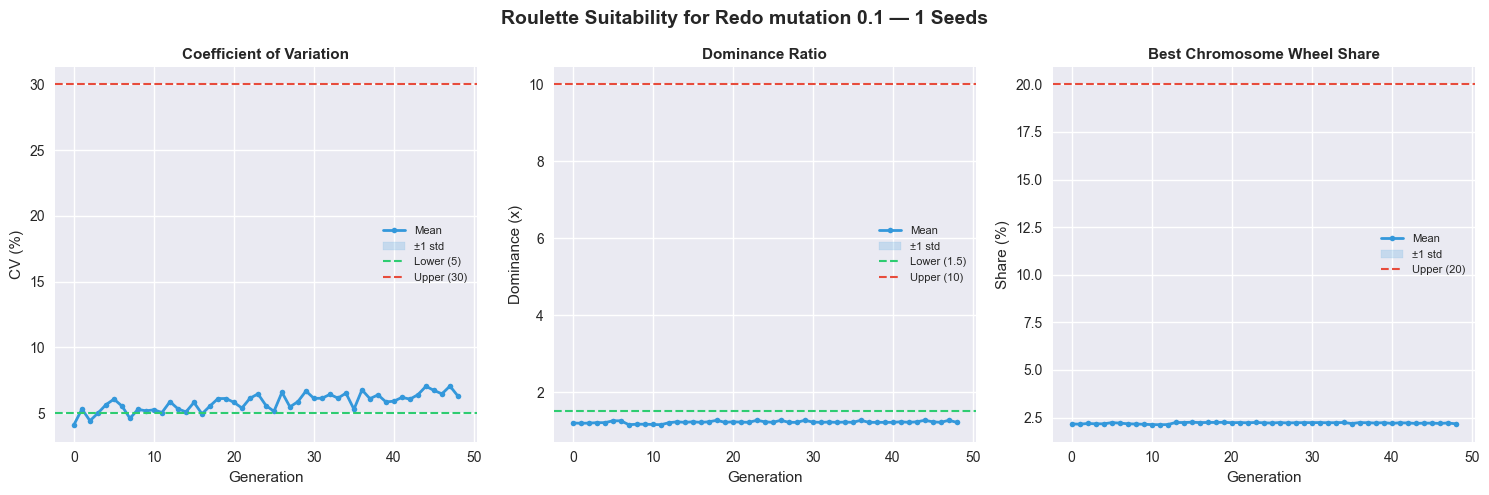

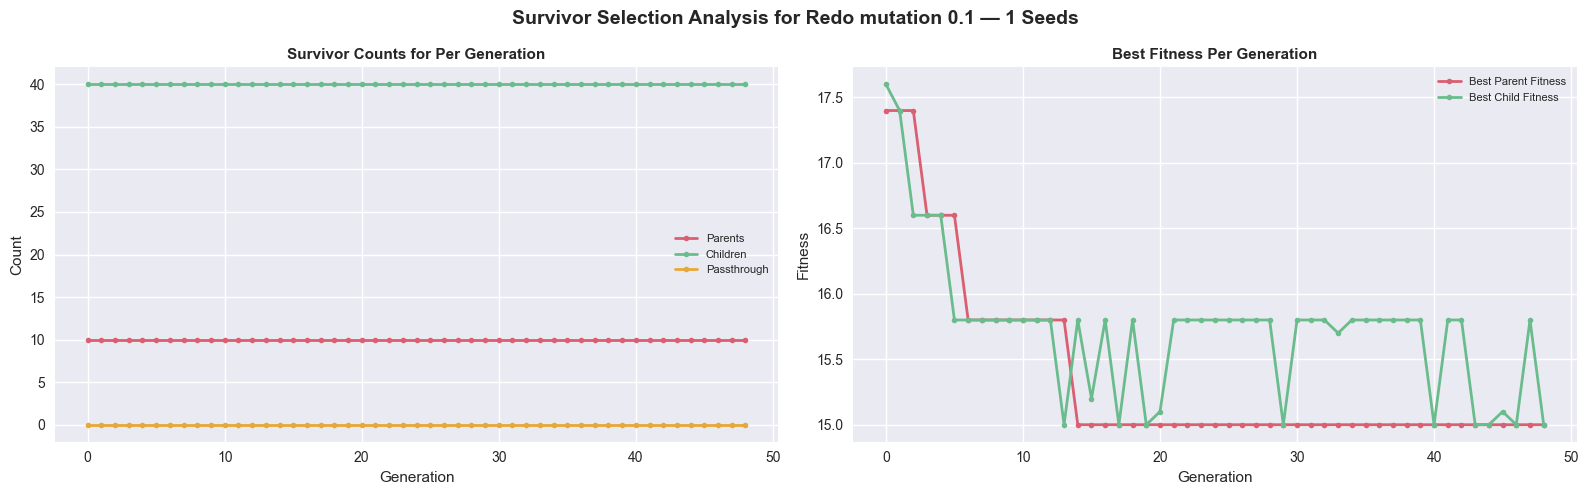

In [26]:
redo_results = extract_results('outputs/tuning/moderate_city_1_test_tournament3.pkl')

plot_parent_selection_stats(evolution_stats=redo_results['evals'],city_name="Redo Mutation 0.1")
plot_survivor_selection(evolution_stats=redo_results['evals'],city_name="Redo Mutation 0.1")


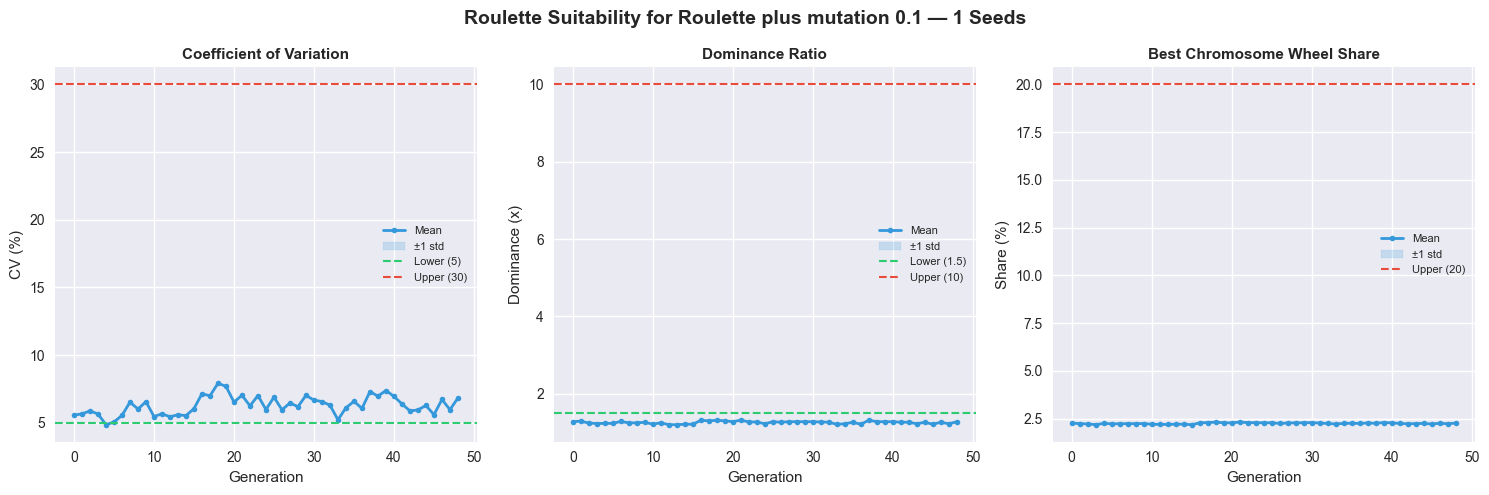

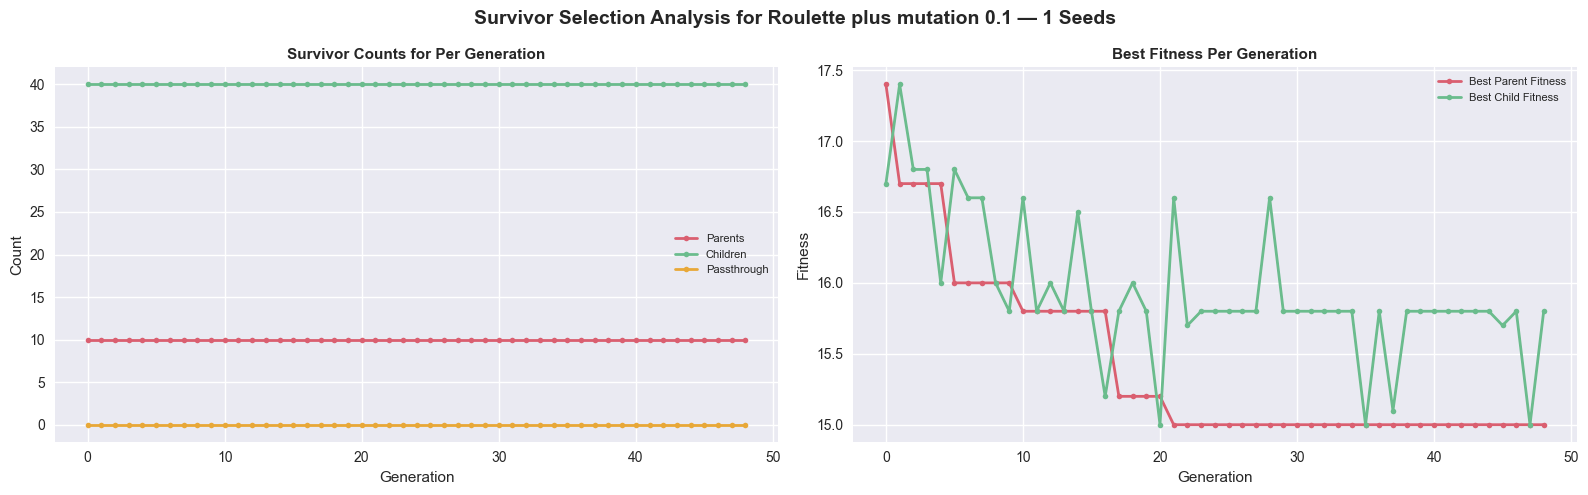

In [27]:
redo_results = extract_results('outputs/tuning/moderate_city_1_test_roulette.pkl')

plot_parent_selection_stats(evolution_stats=redo_results['evals'],city_name="Roulette plus Mutation 0.1")
plot_survivor_selection(evolution_stats=redo_results['evals'],city_name="Roulette plus Mutation 0.1")

Both configs look very similar actually:

Roulette + 10 elites:
CV sitting comfortably above 5%, slightly more variance than tournament
Best parent fitness reaches 15.0 by generation 20 and holds it
Still improving until ~generation 20 then plateaus

Tournament + 10 elites (previous run):
CV also around 5-6%
Best parent fitness reaches 15.0 by generation 15, slightly faster convergence
Children more competitive against parents

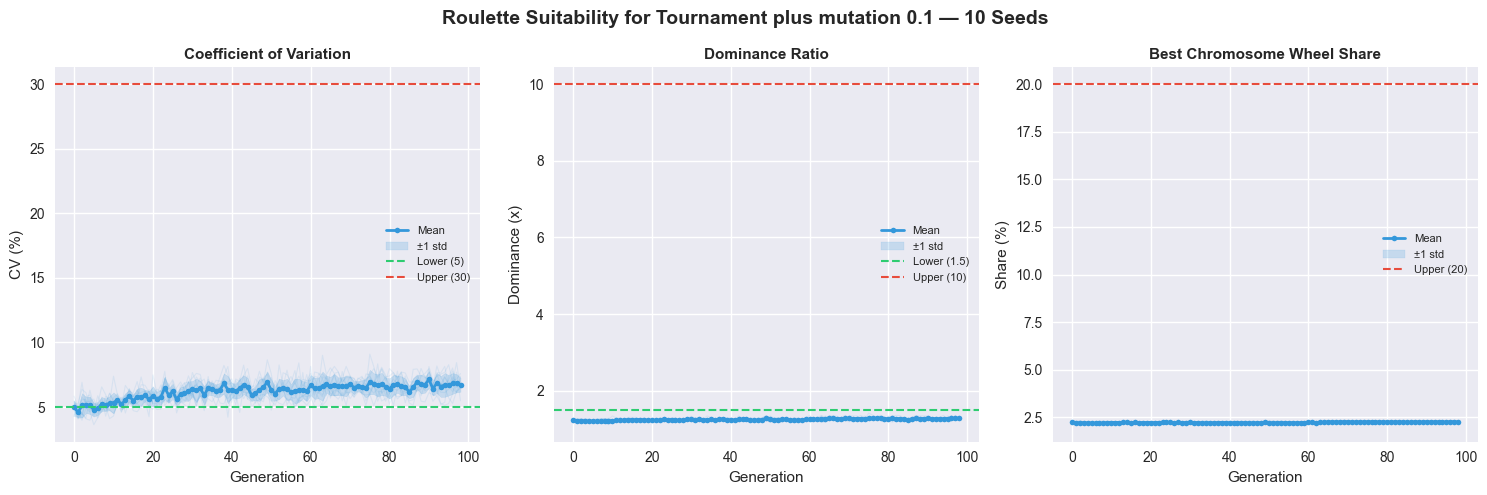

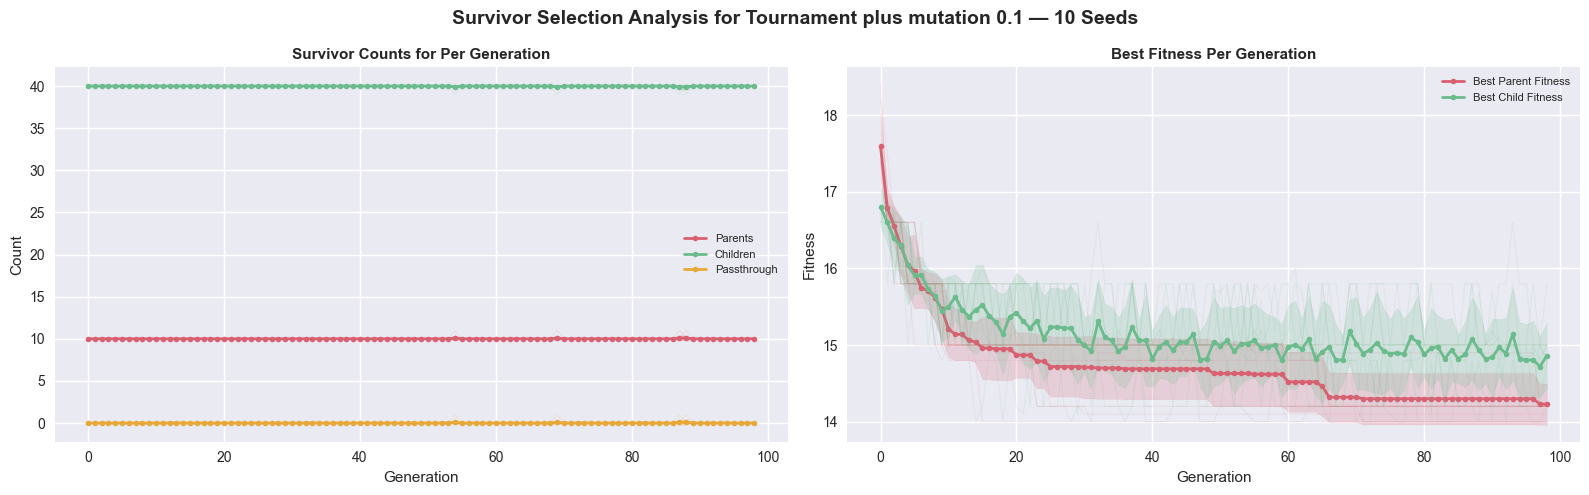

In [28]:
p =  'outputs/tuning/moderate_city_10_100_agents.pkl'

redo_results_more_seeds = extract_results(p)

plot_parent_selection_stats(evolution_stats=redo_results_more_seeds['evals'],city_name="Tournament plus Mutation 0.1")
plot_survivor_selection(evolution_stats=redo_results_more_seeds['evals'],city_name="Tournament plus Mutation 0.1")

## Current Hyperparameters:
```
"fitness": "max-median",
"alpha": 0.8,
"crossover": 0.8,
"mutation": 0.1,
"epsilon": 1,
"max_evolutions": 100,  # 50
"survivor_method": "elite_percentage",
"tournament_size": 3,
```

### Agent Tuning (last one hopefully)
Running the number of agents across all the different citites...

```
cities = ["grid_city", "moderate_city", "bottleneck_city"]
agent_counts = [10, 20, 50, 100, 200]
```

In [29]:
grid_agent_files = {
    'Grid 10 Agents': 'outputs/tuning/grid_city_10_10_agents.pkl',
    'Grid 20 Agents': 'outputs/tuning/grid_city_10_20_agents.pkl',
    'Grid 50 Agents': 'outputs/tuning/grid_city_10_50_agents.pkl',
    'Grid 100 Agents': 'outputs/tuning/grid_city_10_100_agents.pkl',
    'Grid 200 Agents': 'outputs/tuning/grid_city_10_200_agents.pkl',
}
moderate_agent_files = {
    'Moderate 10 Agents': 'outputs/tuning/moderate_city_10_10_agents.pkl',
    'Moderate 20 Agents': 'outputs/tuning/moderate_city_10_20_agents.pkl',
    'Moderate 50 Agents': 'outputs/tuning/moderate_city_10_50_agents.pkl',
    'Moderate 100 Agents': 'outputs/tuning/moderate_city_10_100_agents.pkl',
    'Moderate 200 Agents': 'outputs/tuning/moderate_city_10_200_agents.pkl',
}
bottleneck_agent_files = {
    'Bottleneck 10 Agents': 'outputs/tuning/bottleneck_city_10_10_agents.pkl',
    'Bottleneck 20 Agents': 'outputs/tuning/bottleneck_city_10_20_agents.pkl',
    'Bottleneck 50 Agents': 'outputs/tuning/bottleneck_city_10_50_agents.pkl',
    'Bottleneck 100 Agents': 'outputs/tuning/bottleneck_city_10_100_agents.pkl',
    'Bottleneck 200 Agents': 'outputs/tuning/bottleneck_city_10_200_agents.pkl',
}

cols = [
    'Total time (mean)', 
    'Average time (mean)',
    'Congestion index (mean)', 
    'Avg Congestion delay (mean)',
    'Exit utilisation (mean)', 
    'Avg Path Efficiency (mean)'
]

print('Grid City')
compare_experiments(grid_agent_files)[cols].sort_values('Total time (mean)')

Grid City


,Total time (mean),Average time (mean),Congestion index (mean),Avg Congestion delay (mean),Exit utilisation (mean),Avg Path Efficiency (mean)
experiment,,,,,,
Grid 10 Agents,6.4,5.460,0.020,0.020,0.237,1.032
Grid 20 Agents,8.0,6.095,0.165,0.170,0.240,1.067
Grid 50 Agents,11.6,8.024,0.610,0.866,0.145,1.113
Grid 100 Agents,15.9,10.457,0.840,2.239,0.097,1.185
Grid 200 Agents,22.8,13.997,0.925,5.275,0.052,1.251


In [30]:
print('\nModerate City')
compare_experiments(moderate_agent_files)[cols].sort_values('Total time (mean)')


Moderate City


,Total time (mean),Average time (mean),Congestion index (mean),Avg Congestion delay (mean),Exit utilisation (mean),Avg Path Efficiency (mean)
experiment,,,,,,
Moderate 10 Agents,7.9,6.400,0.020,0.020,0.318,1.038
Moderate 20 Agents,9.1,7.315,0.170,0.175,0.270,1.059
Moderate 50 Agents,11.4,8.700,0.616,0.886,0.127,1.069
Moderate 100 Agents,15.1,10.758,0.842,2.352,0.110,1.115
Moderate 200 Agents,22.3,14.457,0.932,5.643,0.072,1.142


In [31]:
print('\nBottleneck City')
compare_experiments(bottleneck_agent_files)[cols].sort_values('Total time (mean)')


Bottleneck City


,Total time (mean),Average time (mean),Congestion index (mean),Avg Congestion delay (mean),Exit utilisation (mean),Avg Path Efficiency (mean)
experiment,,,,,,
Bottleneck 10 Agents,11.4,10.720,0.140,0.140,0.070,1.010
Bottleneck 20 Agents,13.0,11.755,0.660,0.925,0.197,1.015
Bottleneck 50 Agents,19.5,15.520,0.900,3.984,0.335,1.037
Bottleneck 100 Agents,30.1,21.045,0.950,8.986,0.273,1.055
Bottleneck 200 Agents,50.6,31.428,0.975,19.006,0.234,1.071


### Matching Plots to the Greedy One for the word doc...

In [34]:
import matplotlib.pyplot as plt

def plot_ga_scaling(results: dict, city_name: str) -> None:
    agent_counts = sorted(results.keys())
    metrics = ["Total time", "Average time", "Avg Congestion delay"]
    labels = ["Total Time", "Avg Time", "Avg Congestion Delay"]
    colours = ["#378ADD", "#1D9E75", "#D85A30"]

    fig, ax = plt.subplots(figsize=(10, 6))

    for metric, label, colour in zip(metrics, labels, colours):
        means, stds = [], []

        for n in agent_counts:
            values = [e.metrics[metric] for e in results[n]['evals']]  # <-- key change
            means.append(np.mean(values))
            stds.append(np.std(values))

        means, stds = np.array(means), np.array(stds)
        ax.plot(agent_counts, means, label=label, marker='o', color=colour)
        ax.fill_between(agent_counts, means - stds, means + stds, alpha=0.15, color=colour)

    ax.set_xlabel("Number of Agents")
    ax.set_ylabel("Timesteps")
    ax.set_title(f"GA Routing Performance vs Number of Agents for {city_name} Topology")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

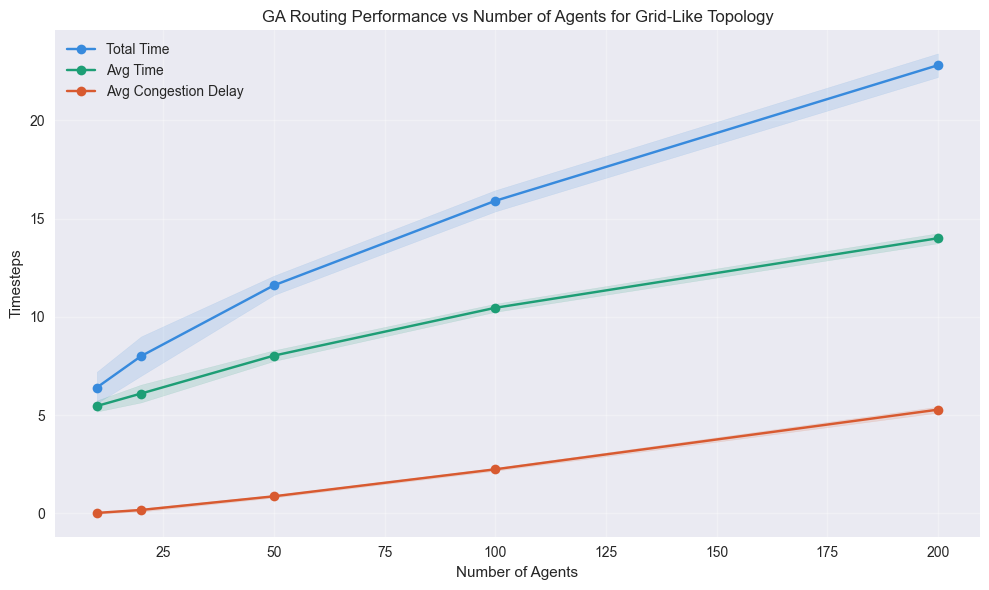

In [35]:
grid_results = {}
for name, path in grid_agent_files.items():
    results = extract_results(path)
    num_agents = int(name.split(' ')[1])
    grid_results[num_agents] = results
    
plot_ga_scaling(grid_results, "Grid-Like")

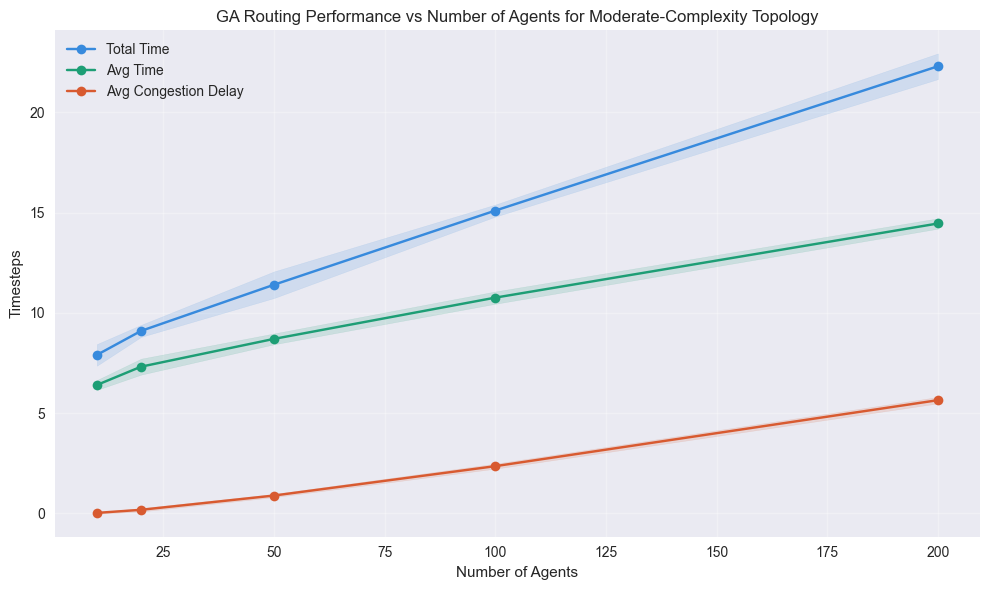

In [36]:
moderate_results = {}
for name, path in moderate_agent_files.items():
    results = extract_results(path)
    num_agents = int(name.split(' ')[1])
    moderate_results[num_agents] = results
    
plot_ga_scaling(moderate_results, "Moderate-Complexity")

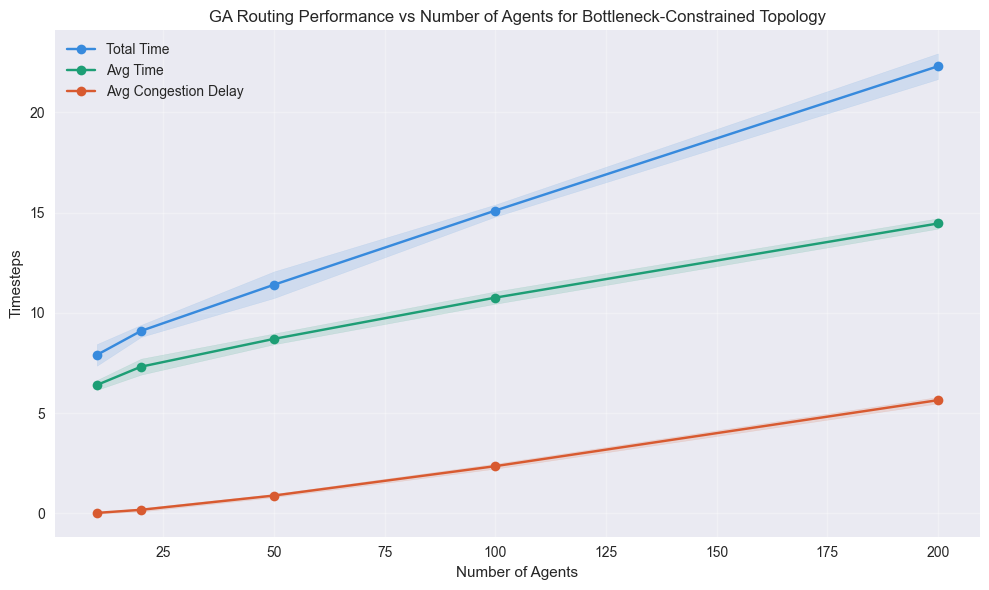

In [37]:
bottleneck_results = {}
for name, path in moderate_agent_files.items():
    results = extract_results(path)
    num_agents = int(name.split(' ')[1])
    bottleneck_results[num_agents] = results
    
plot_ga_scaling(bottleneck_results, "Bottleneck-Constrained")

### Number of Evolutions

In [38]:
num_evolutions_files = {
    'Grid': 'outputs/tuning/grid_city_max_evolutions_results.pkl',
    'Moderate': 'outputs/tuning/moderate_city_max_evolutions_results.pkl',
    'Bottleneck': 'outputs/tuning/bottleneck_city_max_evolutions_results.pkl',
}

In [39]:
import matplotlib.pyplot as plt

def plot_fitness_over_evolutions(files: dict) -> None:
    """
    files: dict keyed by city name, values are file paths to pickled results.
    e.g. {'Grid': 'outputs/...pkl', 'Moderate': '...', 'Bottleneck': '...'}
    """
    cities = list(files.keys())
    n_cities = len(cities)
    colour = "#378ADD"

    fig, axes = plt.subplots(1, n_cities, figsize=(6 * n_cities, 5), sharey=False)
    if n_cities == 1:
        axes = [axes]

    for ax, city in zip(axes, cities):
        results = extract_results(files[city])
        evals = results['ga']['evals']

        # shape: (n_seeds, n_evolutions)
        scores = np.array([e.evolution_scores for e in evals])
        evolutions = np.arange(1, scores.shape[1] + 1)

        mean = scores.mean(axis=0)
        std = scores.std(axis=0)
        best = scores.min(axis=0)   # best seen across seeds
        worst = scores.max(axis=0)  # worst seen across seeds

        ax.plot(evolutions, mean, color=colour, linewidth=1.5, label='Mean')
        ax.fill_between(evolutions, mean - std, mean + std, alpha=0.15, color=colour, label='±1 std')
        ax.plot(evolutions, best, color='#1D9E75', linewidth=1, linestyle='--', label='Best seed')
        ax.plot(evolutions, worst, color='#D85A30', linewidth=1, linestyle='--', label='Worst seed')

        ax.set_title(f"{city} Topology", fontsize=12)
        ax.set_xlabel("Evolution")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Fitness")
    axes[0].legend()
    fig.suptitle("GA Fitness Over Evolutions by Topology", fontsize=14)
    plt.tight_layout()
    plt.show()

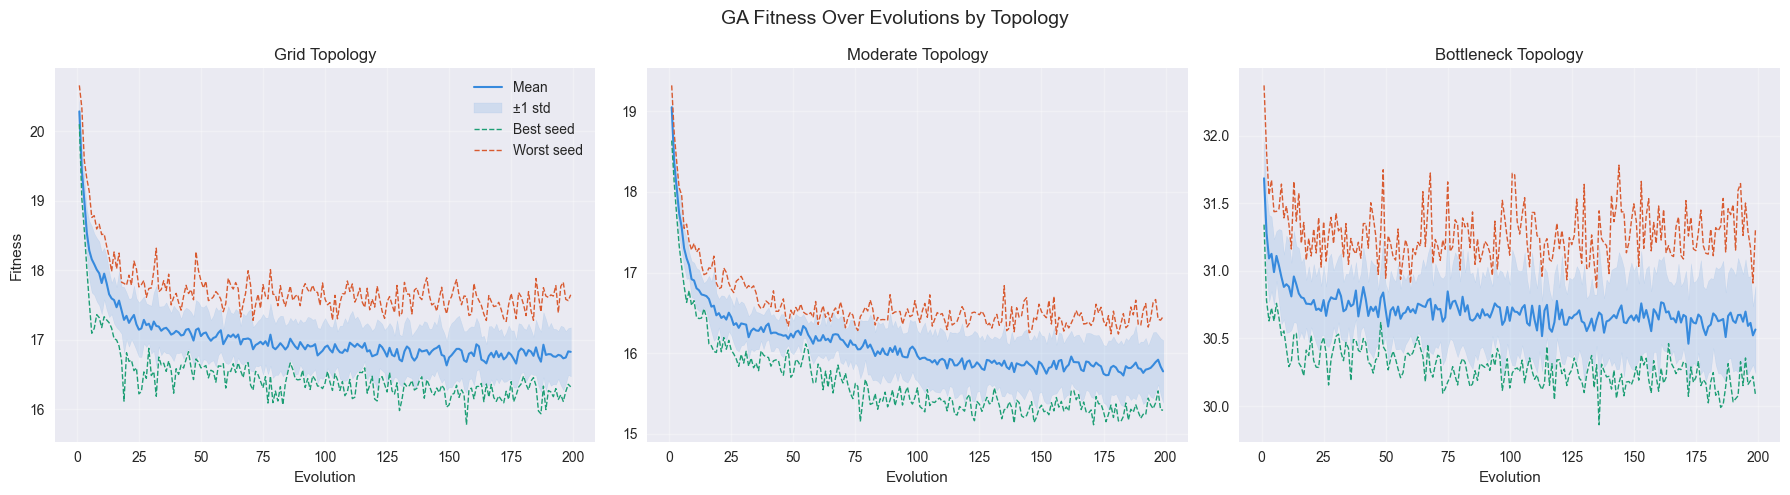

In [40]:
plot_fitness_over_evolutions(num_evolutions_files)

In [41]:
extract_results(num_evolutions_files['Grid'])['ga']['n_experiments']

10

In [42]:
main_experiment = extract_results('outputs/runs/moderate_city_Truewalking_Truedelay_0compliance.pkl')